<a href="https://colab.research.google.com/github/sapienology/deep-learning-projects/blob/main/fashion_mnist_nitdev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Clothing Classifier Model](images/Clothing%20Classifier%20Model.png)

_Fashion Forward_ is a new AI-based e-commerce clothing retailer. They want to use image classification to automatically categorize new product listings, making it easier for customers to find what they're looking for. It will also assist in inventory management by quickly sorting items.

As a data scientist tasked with implementing a clothing classifier, your primary objective is to develop a deep learning model capable of accurately categorizing images of clothing items into distinct garment types such as shirts, trousers, shoes, etc.

In [5]:
# Run the cells below first
from tensorflow.keras import layers, models, Sequential
from keras.layers import Dense, Conv2D, Flatten
from tensorflow.keras.utils import to_categorical
import numpy as np

# Unzip the dataset file first
!unzip -o /content/fashion_mnist.npz.zip -d /content/

# Load the MNIST datasets as NumPy arrays from the unzipped files
train_images = np.load('/content/train_images.npy')
train_labels = np.load('/content/train_labels.npy')
test_images = np.load('/content/test_images.npy')
test_labels = np.load('/content/test_labels.npy')

Archive:  /content/fashion_mnist.npz.zip
  inflating: /content/train_images.npy  
  inflating: /content/train_labels.npy  
  inflating: /content/test_images.npy  
  inflating: /content/test_labels.npy  


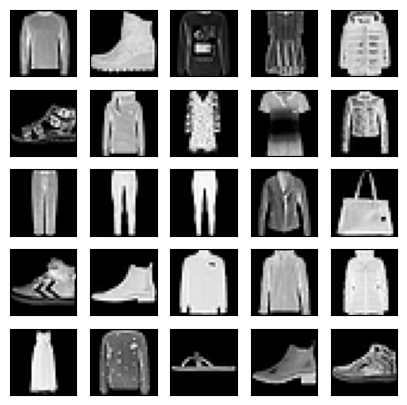

In [6]:
# Visualize a sample of images
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i]/255.0, cmap='gray')
plt.show()

In [7]:
# Define the CNN model
model = Sequential([
    # First convolutional layer
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    # Second convolutional layer
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    # Flatten the output
    Flatten(),
    # Dense layer - Neural Network
    Dense(128, activation='relu'),
    # Output layer (10 classes for Fashion MNIST)
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile the CNN model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Converting the labels
Convert the labels to the appropriate format.


Convert the integer labels to categorical/one-hot encoded labels
You can use Keras's to_categorical() function to do this.

In [9]:
from tensorflow.keras.utils import to_categorical

# Assuming train_labels and test_labels are your label arrays
train_labels_cat = to_categorical(train_labels, num_classes=10)
test_labels_cat = to_categorical(test_labels, num_classes=10)

# Display the shape of the new label arrays
print('train_labels_cat shape:', train_labels_cat.shape)
print('test_labels_cat shape:', test_labels_cat.shape)

train_labels_cat shape: (30000, 10)
test_labels_cat shape: (5000, 10)


Fitting the model
Fit the model on the given training data.


Fit the model on the given training data specifying the number of epochs
Call the .fit() method passing in the training images, training labels, and epochs.

Is this hint helpful?




Fitting the Model
-----------------

Now, let's fit the compiled CNN model to the training data. We'll use the `.fit()` method, specifying the training images, one-hot encoded training labels, and the number of epochs.

You can also specify additional parameters such as `batch_size` and `validation_data` if you wish to monitor validation performance during training.

In [ ]:
# Fit the model on the training data
# Assuming train_images and train_labels_cat are already defined
# You can adjust epochs and batch_size as needed

history = model.fit(
    train_images,
    train_labels_cat,
    epochs=15,           # You can change the number of epochs
    batch_size=32,       # You can change the batch size
    validation_split=0.2 # Use 20% of training data for validation
)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 177s 233ms/step - accuracy: 0.8070 - loss: 1.0613 - val_accuracy: 0.8433 - val_loss: 0.4480
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 172s 229ms/step - accuracy: 0.8733 - loss: 0.3376 - val_accuracy: 0.8662 - val_loss: 0.3701
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 172s 229ms/step - accuracy: 0.9060 - loss: 0.2517 - val_accuracy: 0.8753 - val_loss: 0.3681
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 203s 230ms/step - accuracy: 0.9295 - loss: 0.1859 - val_accuracy: 0.8842 - val_loss: 0.3756
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 202s 230ms/step - accuracy: 0.9452 - loss: 0.1468 - val_accuracy: 0.8727 - val_loss: 0.4354
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 202s 230ms/step - accuracy: 0.9636 - loss: 0.1004 - val_accuracy: 0.8753 - val_loss: 0.5236
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 187s 249ms/step - accuracy: 0.9660 - loss: 0.0946 - val_accuracy: 0.8762 - val_loss: 0.5499
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 198s 244ms/step - accuracy: 0.9749 -

In [ ]:
model.save('fashion_mnist_model.h5')

Testing the model
Test the model on the test data, and calculate the accuracy.


Test the model on the test data
You can use the .evaluate() method on your model, passing in the test images and test labels.
This will return a list of scores, one of which will be the accuracy.

Is this hint helpful?



In [ ]:
# Define or load the model before evaluating
# Example: Load a saved model (update the path as needed)
from tensorflow.keras.models import load_model

# Replace 'path_to_your_model.h5' with the actual path to your saved model file
model = load_model('fashion_mnist_model.h5')

# Evaluate the model on the test data
# Assuming test_images and test_labels_cat are already defined

test_loss, test_accuracy = model.evaluate(test_images, test_labels_cat, verbose=2)

from IPython.display import display, #Markdown

display(Markdown(f"Test Loss: {test_loss:.4f}"))
display(Markdown(f"Test Accuracy: {test_accuracy:.4f}"))